In [32]:
import pandas as pd

data_path = "scored_essays.csv"
df = pd.read_csv(data_path)
df.head()

,Order ID,Category,File ID,Essay Rating,Document Content,Essay Content,PST Score,Specificity Score,Pace Score,VSPICE Score,Creativity Score
0,F12E2846T1,CAPS,1dcQLzZs956CwF0UeRQfNslNnmoxZZPeuH_k-P4bQoOk,7.5-8,Xocthavy has previously uploaded this essay to...,"“Hee mae mg!” (fool), my grandpa yells, his te...",6.72,7.0,8.0,8.2,7.8
1,F12E2839T1,CAPS,1-EgLAy8xLzYU-J6MLeMEBoKcyH078rDG1cR6tVqPJkw,7.5-8,Requested Type of Feedback: Editor’s Choice (a...,"At three a.m., I found myself once again surro...",6.02,7.5,8.0,8.5,7.5
2,F12E2837T1,CAPS,12ksiJh3V9QhCzFiC19KQIVobnhPY6SyNkvJuXoK9wes,7,Requested Type of Feedback: Editor’s Choice (a...,The year is 1983. My father’s family flees Sri...,2.42,8.5,9.0,8.3,8.5
3,F12E2826T1,CAPS,1vDgdZWPCMWvSgv11QDocKpB6d1ej2wK3vcQru5ndZnM,6.5,Requested Type of Feedback: Editor’s Choice (a...,I was practicing “Waltz in A Minor” at the pia...,4.95,6.5,8.3,8.0,6.5
4,F12E2818T1,CAPS,1rqe4sPd9Tv8R2o2sCjfkInMexfZTcPDdC9jrW87ZOfI,6,Requested Type of Feedback: Editor’s Choice (a...,I thought mastering yoga would make me a super...,7.44,7.5,8.2,8.2,5.5


In [33]:
import pandas as pd
import numpy as np

def rating_to_number(val):
    if pd.isna(val):
        return np.nan
    if val == "<5":
        return 4.0
    try:
        return float(val)
    except ValueError:
        if "-" in val:
            parts = val.split("-")
            try:
                nums = [float(p) for p in parts]
                return sum(nums) / len(nums)
            except:
                return np.nan
        return np.nan


# Example usage:
df["Essay Rating"] = df["Essay Rating"].apply(rating_to_number)

df.head()

,Order ID,Category,File ID,Essay Rating,Document Content,Essay Content,PST Score,Specificity Score,Pace Score,VSPICE Score,Creativity Score
0,F12E2846T1,CAPS,1dcQLzZs956CwF0UeRQfNslNnmoxZZPeuH_k-P4bQoOk,7.75,Xocthavy has previously uploaded this essay to...,"“Hee mae mg!” (fool), my grandpa yells, his te...",6.72,7.0,8.0,8.2,7.8
1,F12E2839T1,CAPS,1-EgLAy8xLzYU-J6MLeMEBoKcyH078rDG1cR6tVqPJkw,7.75,Requested Type of Feedback: Editor’s Choice (a...,"At three a.m., I found myself once again surro...",6.02,7.5,8.0,8.5,7.5
2,F12E2837T1,CAPS,12ksiJh3V9QhCzFiC19KQIVobnhPY6SyNkvJuXoK9wes,7.00,Requested Type of Feedback: Editor’s Choice (a...,The year is 1983. My father’s family flees Sri...,2.42,8.5,9.0,8.3,8.5
3,F12E2826T1,CAPS,1vDgdZWPCMWvSgv11QDocKpB6d1ej2wK3vcQru5ndZnM,6.50,Requested Type of Feedback: Editor’s Choice (a...,I was practicing “Waltz in A Minor” at the pia...,4.95,6.5,8.3,8.0,6.5
4,F12E2818T1,CAPS,1rqe4sPd9Tv8R2o2sCjfkInMexfZTcPDdC9jrW87ZOfI,6.00,Requested Type of Feedback: Editor’s Choice (a...,I thought mastering yoga would make me a super...,7.44,7.5,8.2,8.2,5.5


In [39]:
# List your target score columns
score_columns = ["PST Score", "Specificity Score", "Pace Score", "VSPICE Score", "Creativity Score"]

# First, convert everything to numeric (will turn non-numeric values into NaN)
df[score_columns] = df[score_columns].apply(pd.to_numeric, errors='coerce')

# Drop any row that has NaN in any of those score columns
df = df.dropna(subset=score_columns)

df.head()

,Unnamed: 0,Order ID,Category,File ID,Essay Rating,Document Content,Essay Content,PST Score,Specificity Score,Pace Score,VSPICE Score,Creativity Score
0,0,F12E2846T1,CAPS,1dcQLzZs956CwF0UeRQfNslNnmoxZZPeuH_k-P4bQoOk,7.75,Xocthavy has previously uploaded this essay to...,"“Hee mae mg!” (fool), my grandpa yells, his te...",6.72,7.0,8.0,8.2,7.8
1,1,F12E2839T1,CAPS,1-EgLAy8xLzYU-J6MLeMEBoKcyH078rDG1cR6tVqPJkw,7.75,Requested Type of Feedback: Editor’s Choice (a...,"At three a.m., I found myself once again surro...",6.02,7.5,8.0,8.5,7.5
2,2,F12E2837T1,CAPS,12ksiJh3V9QhCzFiC19KQIVobnhPY6SyNkvJuXoK9wes,7.00,Requested Type of Feedback: Editor’s Choice (a...,The year is 1983. My father’s family flees Sri...,2.42,8.5,9.0,8.3,8.5
3,3,F12E2826T1,CAPS,1vDgdZWPCMWvSgv11QDocKpB6d1ej2wK3vcQru5ndZnM,6.50,Requested Type of Feedback: Editor’s Choice (a...,I was practicing “Waltz in A Minor” at the pia...,4.95,6.5,8.3,8.0,6.5
4,4,F12E2818T1,CAPS,1rqe4sPd9Tv8R2o2sCjfkInMexfZTcPDdC9jrW87ZOfI,6.00,Requested Type of Feedback: Editor’s Choice (a...,I thought mastering yoga would make me a super...,7.44,7.5,8.2,8.2,5.5


In [40]:
df.shape

(1177, 12)

In [1]:
df.to_csv("scored_essays_final.csv")

NameError: name 'df' is not defined

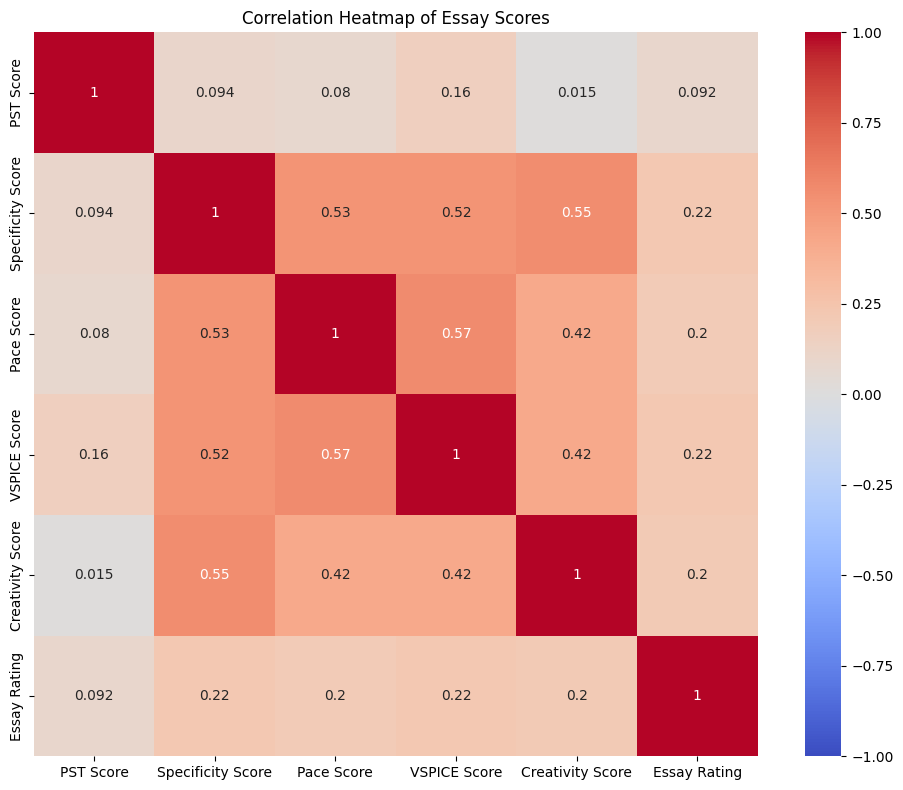

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("scored_essays_final.csv")

# Select the relevant columns
cols_to_plot = ["PST Score", "Specificity Score", "Pace Score", "VSPICE Score", "Creativity Score", "Essay Rating"]

# Compute correlation matrix
corr = df[cols_to_plot].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap of Essay Scores")
plt.tight_layout()
plt.show()

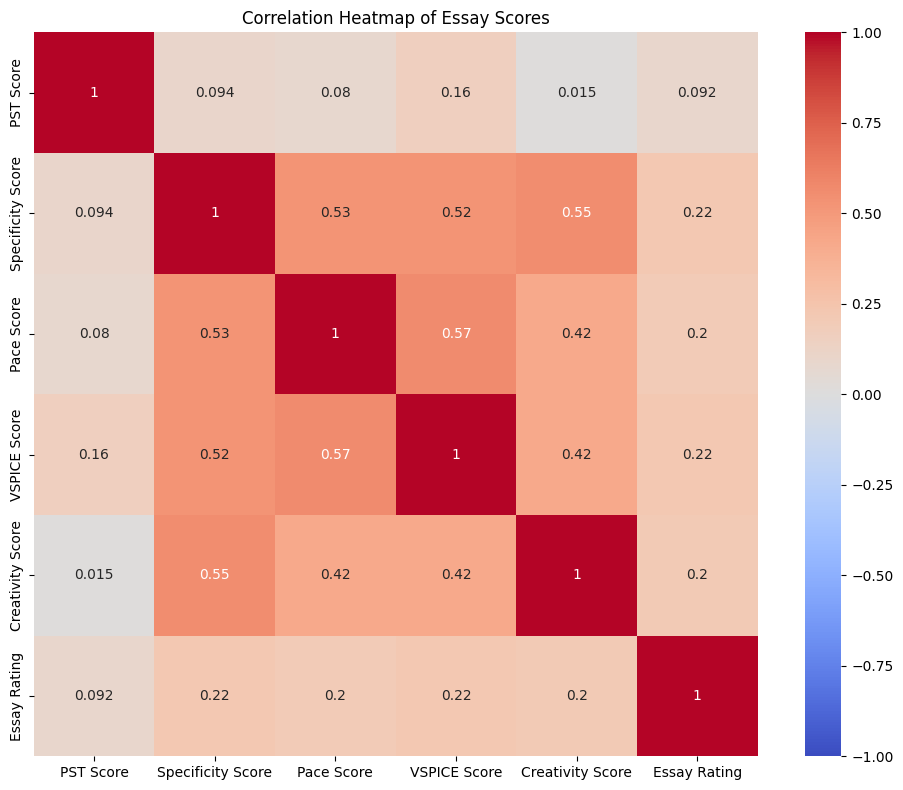

In [7]:
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap of Essay Scores")
plt.tight_layout()

# Save the figure
plt.savefig("correlation_heatmap.png", dpi=300)  # You can also use .pdf, .svg, etc.

# Display the plot
plt.show()

In [8]:
df_copy = df
threshold = 5.0
score_columns = ["Specificity Score", "Pace Score", "VSPICE Score", "Creativity Score"]

# Check if any score is below the threshold
df["has_low_score"] = df[score_columns].lt(threshold).any(axis=1)
low = df[df["has_low_score"] == True]["Essay Rating"]
high = df[df["has_low_score"] == False]["Essay Rating"]

print("Average Essay Rating when any score is low:", low.mean())
print("Average Essay Rating when no scores are low:", high.mean())

Average Essay Rating when any score is low: 5.4914529914529915
Average Essay Rating when no scores are low: 5.929952830188679


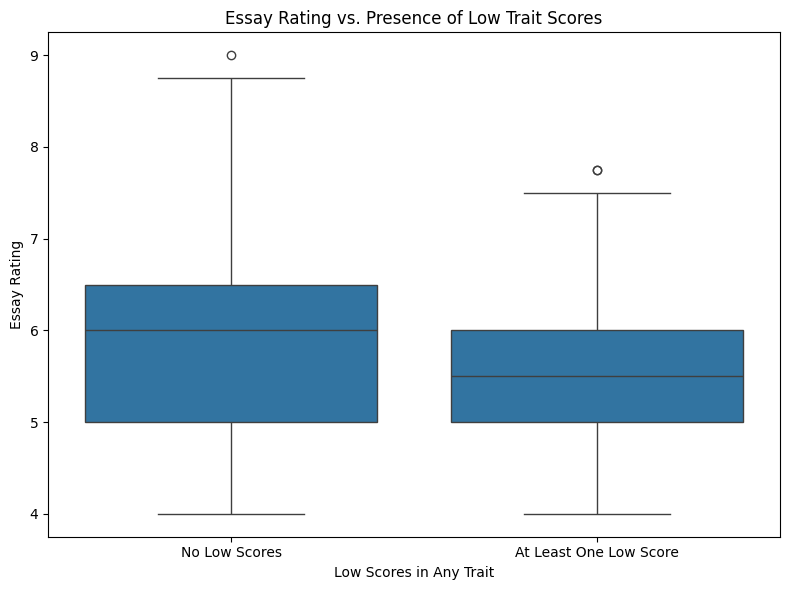

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x="has_low_score", y="Essay Rating", data=df)
plt.xticks([0, 1], ["No Low Scores", "At Least One Low Score"])
plt.title("Essay Rating vs. Presence of Low Trait Scores")
plt.xlabel("Low Scores in Any Trait")
plt.ylabel("Essay Rating")
plt.tight_layout()
plt.show()

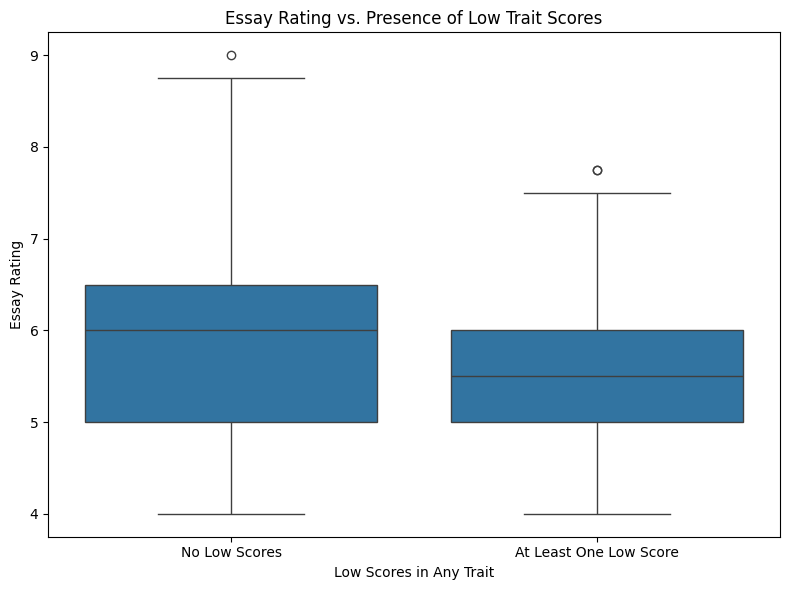

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x="has_low_score", y="Essay Rating", data=df)
plt.xticks([0, 1], ["No Low Scores", "At Least One Low Score"])
plt.title("Essay Rating vs. Presence of Low Trait Scores")
plt.xlabel("Low Scores in Any Trait")
plt.ylabel("Essay Rating")
plt.tight_layout()

# Save the plot
plt.savefig("low_score_boxplot.png", dpi=300)

# Display the plot
plt.show()


In [46]:
from scipy.stats import ttest_ind

group_no_low = df[df["has_low_score"] == False]["Essay Rating"]
group_with_low = df[df["has_low_score"] == True]["Essay Rating"]

# Drop NaNs just in case
group_no_low = group_no_low.dropna()
group_with_low = group_with_low.dropna()

# Perform Welch’s t-test
t_stat, p_val = ttest_ind(group_no_low, group_with_low, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ Statistically significant difference!")
else:
    print("❌ No statistically significant difference.")


T-statistic: 4.9155
P-value: 0.0000
✅ Statistically significant difference!


In [47]:
# Random Forest Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("scored_essays_final.csv")

# Define features and target
score_columns = ["PST Score", "Specificity Score", "Pace Score", "VSPICE Score", "Creativity Score"]
X = df[score_columns]
y = df["Essay Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R² Score: -0.0032
Mean Squared Error: 1.0038


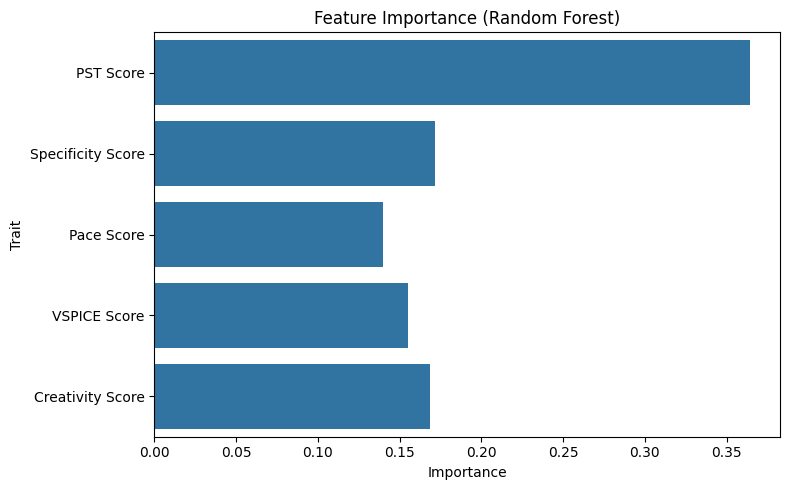

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=score_columns)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Trait")
plt.tight_layout()
plt.show()


In [52]:
# Lol that didn't work, let's try something else...

from sklearn.feature_extraction.text import TfidfVectorizer

# Assume you have a column called 'Essay Text'
tfidf = TfidfVectorizer(max_features=300, stop_words='english')  # limit size to avoid overfitting
X_text = tfidf.fit_transform(df["Essay Content"]).toarray()

# Convert to DataFrame
text_features = pd.DataFrame(X_text, columns=tfidf.get_feature_names_out())

X_combined = pd.concat([df[score_columns].reset_index(drop=True), text_features], axis=1)
y_combined = df["Essay Rating"]

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_squared_error

print("R^2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R^2: 0.15538926813950882
MSE: 0.8451452860169493


In [60]:
# Lets try this...
%pip install transformers sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [3]:
from sentence_transformers import SentenceTransformer
import pandas as pd

df = pd.read_csv("scored_essays_final.csv")

# Load a sentence-level BERT encoder
model = SentenceTransformer("all-MiniLM-L6-v2")  # fast & good for general embeddings

# Generate embeddings (each essay becomes a 384-dim vector)
embeddings = model.encode(df["Essay Content"].tolist(), show_progress_bar=True)

/home/cpsc415_jk2783/.conda/envs/elevator_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 37/37 [00:03<00:00,  9.85it/s]


In [4]:
import pandas as pd
import numpy as np

score_columns = ["PST Score", "Specificity Score", "Pace Score", "VSPICE Score", "Creativity Score"]

# Create DataFrame of embeddings
embed_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(embeddings.shape[1])])

# Combine with existing trait scores
X = pd.concat([df[score_columns].reset_index(drop=True), embed_df], axis=1)
y = df["Essay Rating"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R² Score: 0.1554
Mean Squared Error: 0.8451
